# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Student Data Dataset](https://www.kaggle.com/datasets/arpitsharmaml/student-academic-risk-prediction-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('student_data_100000.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,attendance,study_hours,past_failures,assignments_completed_pct,parental_education,family_income,extracurricular,internet_access,previous_grade,final_score,risk_category
0,87.42,10.12,2,100.00,Secondary,Low,Yes,Yes,46.80,76.08,Safe
1,71.54,1.38,3,36.70,Secondary,High,Yes,Yes,48.05,43.21,High-Risk
2,91.19,8.30,5,64.38,Secondary,Low,No,Yes,69.40,60.89,At-Risk
3,100.00,3.52,4,93.77,Secondary,Low,No,No,58.07,45.47,At-Risk
4,69.15,4.69,1,72.36,Primary,Low,Yes,Yes,50.55,37.15,High-Risk


## last Five row

In [4]:
df.tail()

,attendance,study_hours,past_failures,assignments_completed_pct,parental_education,family_income,extracurricular,internet_access,previous_grade,final_score,risk_category
99995,69.37,0.94,1,53.35,Higher,Medium,No,Yes,100.00,61.89,High-Risk
99996,60.76,8.26,2,65.04,Primary,Low,Yes,Yes,100.00,90.91,At-Risk
99997,85.23,6.64,1,45.57,Secondary,Medium,No,Yes,40.19,57.30,At-Risk
99998,69.72,9.42,3,44.28,Secondary,Low,No,Yes,93.55,51.50,At-Risk
99999,78.00,1.74,5,54.33,Higher,High,Yes,Yes,40.74,41.12,High-Risk


## Shape of our dataset

In [5]:
df.shape

(100000, 11)

## List out all columns

In [6]:
df.columns

Index(['attendance', 'study_hours', 'past_failures',
       'assignments_completed_pct', 'parental_education', 'family_income',
       'extracurricular', 'internet_access', 'previous_grade', 'final_score',
       'risk_category'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

attendance                   float64
study_hours                  float64
past_failures                  int64
assignments_completed_pct    float64
parental_education            object
family_income                 object
extracurricular               object
internet_access               object
previous_grade               float64
final_score                  float64
risk_category                 object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   attendance                 99000 non-null   float64
 1   study_hours                99000 non-null   float64
 2   past_failures              100000 non-null  int64  
 3   assignments_completed_pct  100000 non-null  float64
 4   parental_education         100000 non-null  object 
 5   family_income              100000 non-null  object 
 6   extracurricular            100000 non-null  object 
 7   internet_access            100000 non-null  object 
 8   previous_grade             100000 non-null  float64
 9   final_score                100000 non-null  float64
 10  risk_category              100000 non-null  object 
dtypes: float64(5), int64(1), object(5)
memory usage: 8.4+ MB


## Check Null Value

In [9]:
df.isnull().sum()

attendance                   1000
study_hours                  1000
past_failures                   0
assignments_completed_pct       0
parental_education              0
family_income                   0
extracurricular                 0
internet_access                 0
previous_grade                  0
final_score                     0
risk_category                   0
dtype: int64

## Handle Null Values

In [10]:
df["attendance"] = df["attendance"].fillna(df["attendance"].median())
df["study_hours"] = df["study_hours"].fillna(df["study_hours"].median())

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,attendance,study_hours,past_failures,assignments_completed_pct,previous_grade,final_score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,72.993491,6.100882,1.848650,72.929616,72.967067,62.968236
std,21.455659,3.703867,1.491297,21.656246,21.624269,15.888285
min,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,58.360000,3.340000,1.000000,58.090000,58.190000,52.220000
50%,75.065000,6.000000,2.000000,75.070000,75.040000,63.160000
75%,91.740000,8.660000,3.000000,91.830000,91.890000,73.990000
max,100.000000,15.000000,5.000000,100.000000,100.000000,100.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

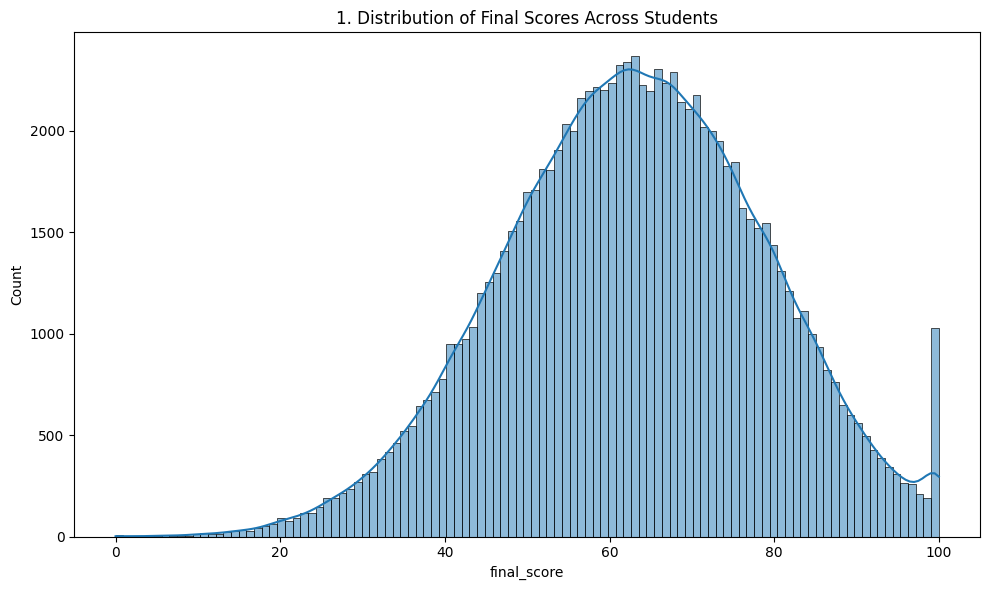

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='final_score', kde=True)
plt.title(f'{plot_no}. Distribution of Final Scores Across Students')
show_fig()
plot_no += 1

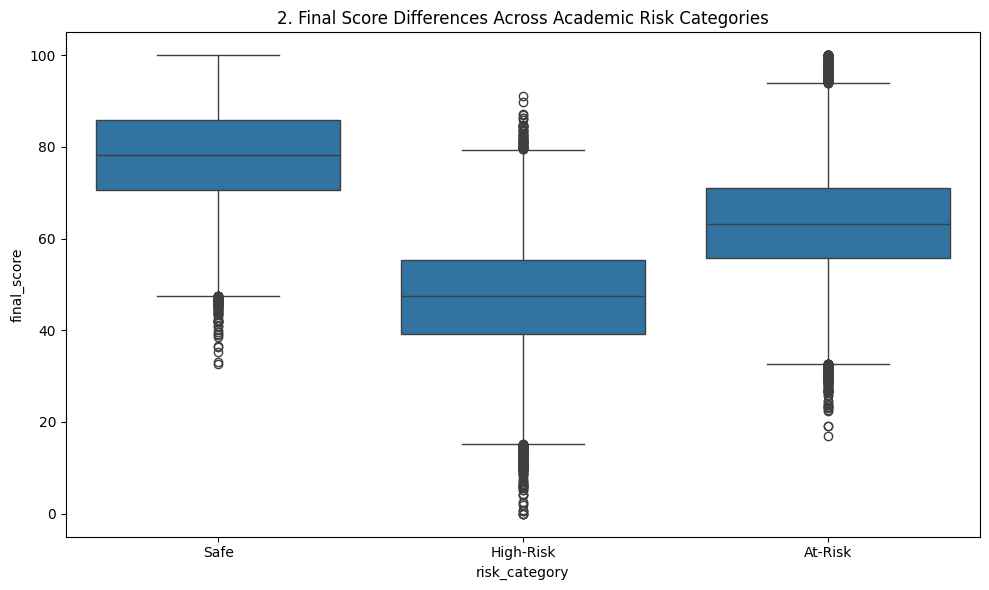

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='risk_category', y='final_score')
plt.title(f'{plot_no}. Final Score Differences Across Academic Risk Categories')
show_fig()
plot_no += 1

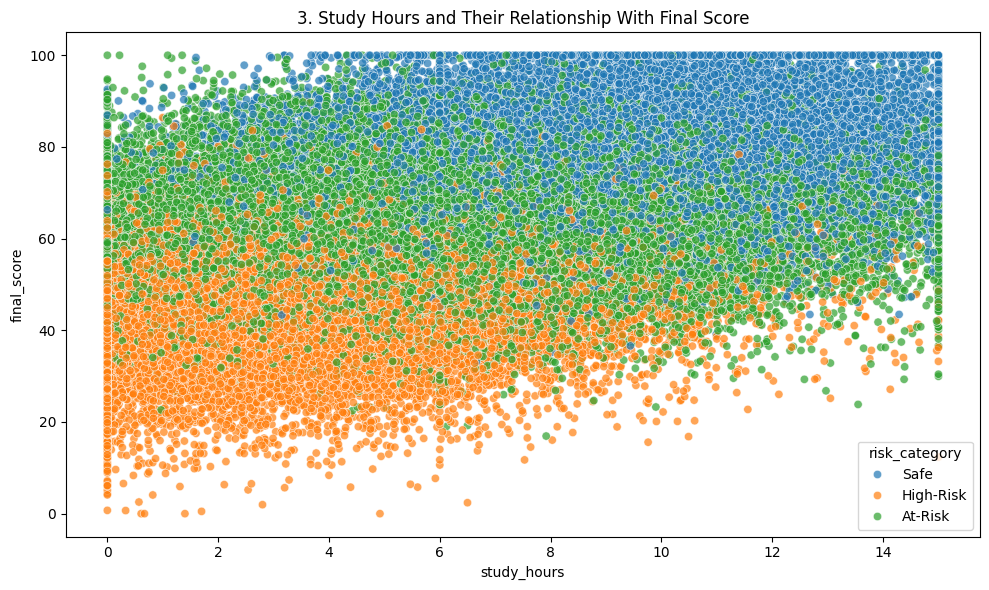

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='study_hours', y='final_score', hue='risk_category', alpha=0.7)
plt.title(f'{plot_no}. Study Hours and Their Relationship With Final Score')
show_fig()
plot_no += 1

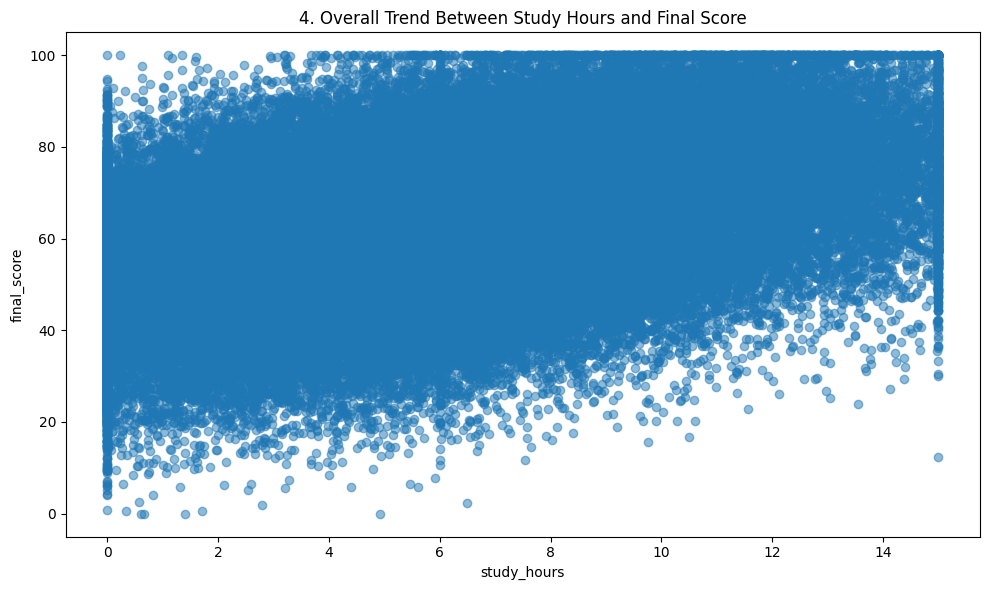

In [17]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='study_hours', y='final_score', scatter_kws={'alpha':0.5})
plt.title(f'{plot_no}. Overall Trend Between Study Hours and Final Score')
show_fig()
plot_no += 1

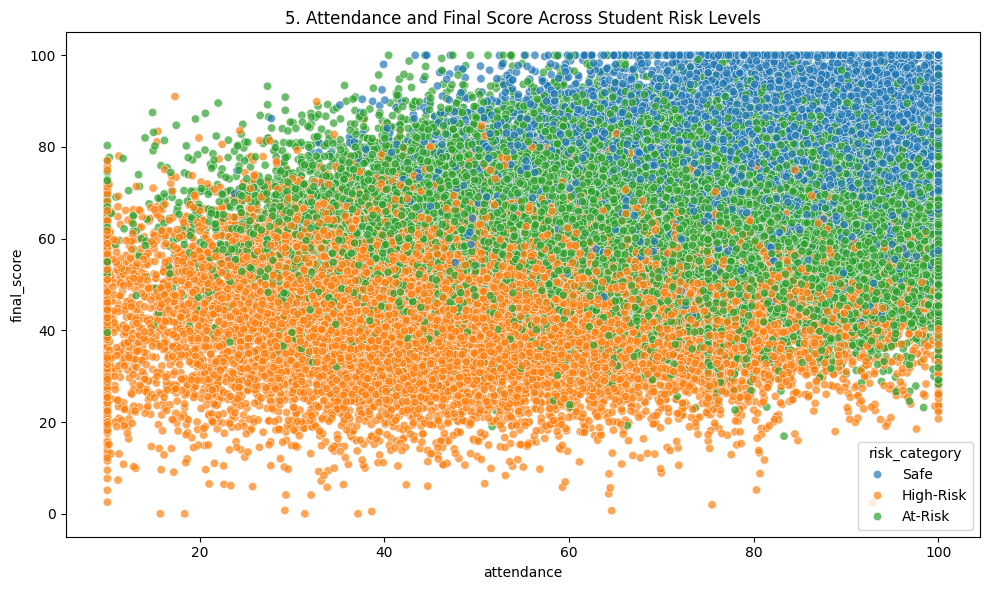

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='attendance', y='final_score', hue='risk_category', alpha=0.7)
plt.title(f'{plot_no}. Attendance and Final Score Across Student Risk Levels')
show_fig()
plot_no += 1

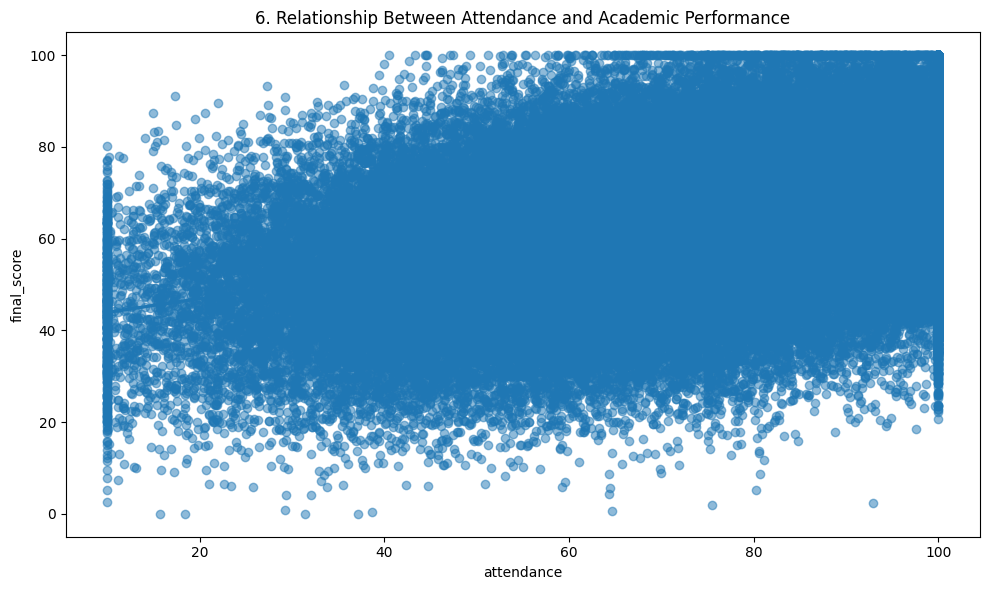

In [19]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='attendance', y='final_score', scatter_kws={'alpha':0.5})
plt.title(f'{plot_no}. Relationship Between Attendance and Academic Performance')
show_fig()
plot_no += 1

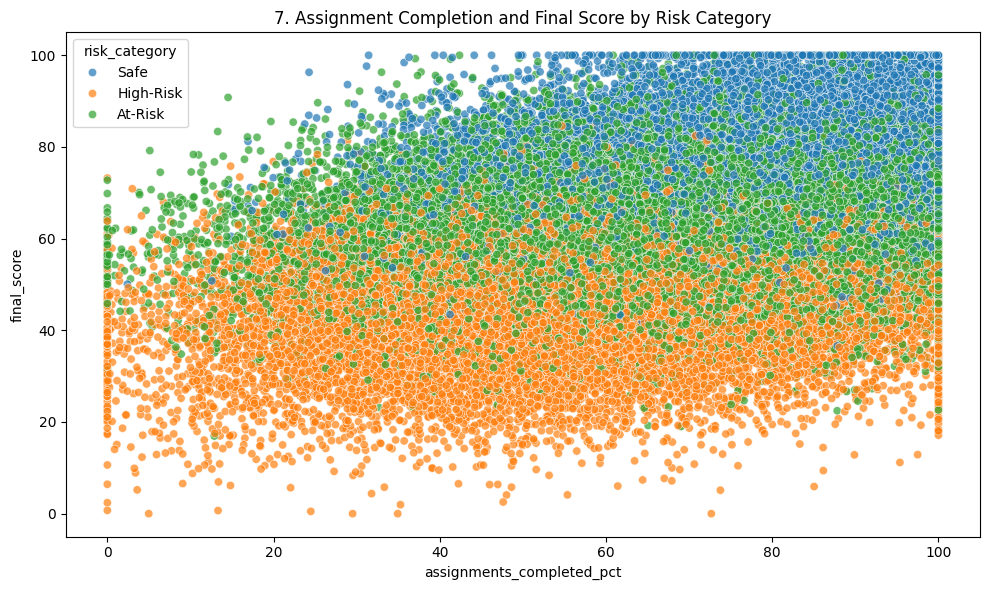

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='assignments_completed_pct', y='final_score', hue='risk_category', alpha=0.7)
plt.title(f'{plot_no}. Assignment Completion and Final Score by Risk Category')
show_fig()
plot_no += 1

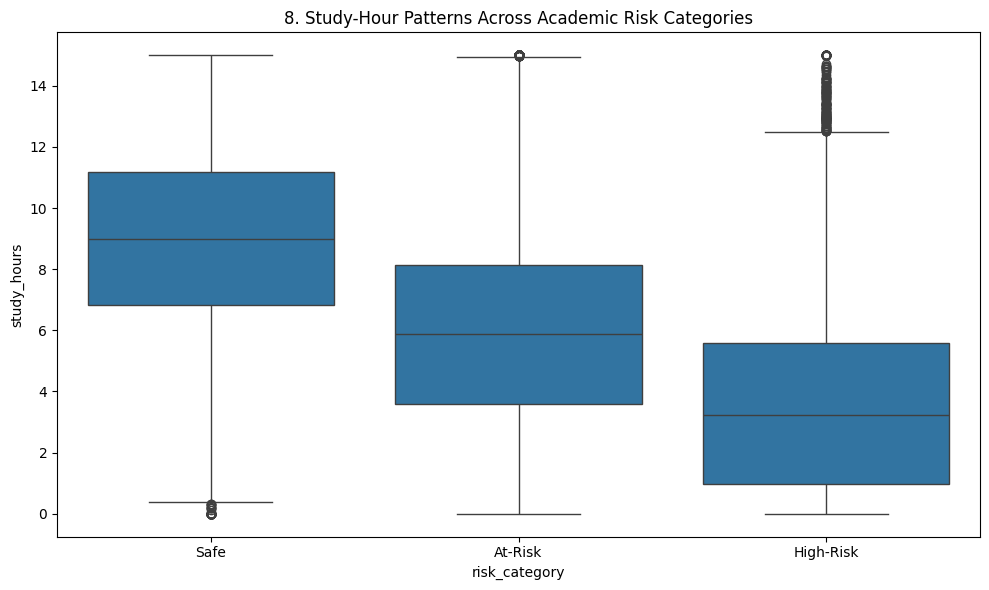

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='risk_category', y='study_hours', order=['Safe', 'At-Risk', 'High-Risk'])
plt.title(f'{plot_no}. Study-Hour Patterns Across Academic Risk Categories')
show_fig()
plot_no += 1

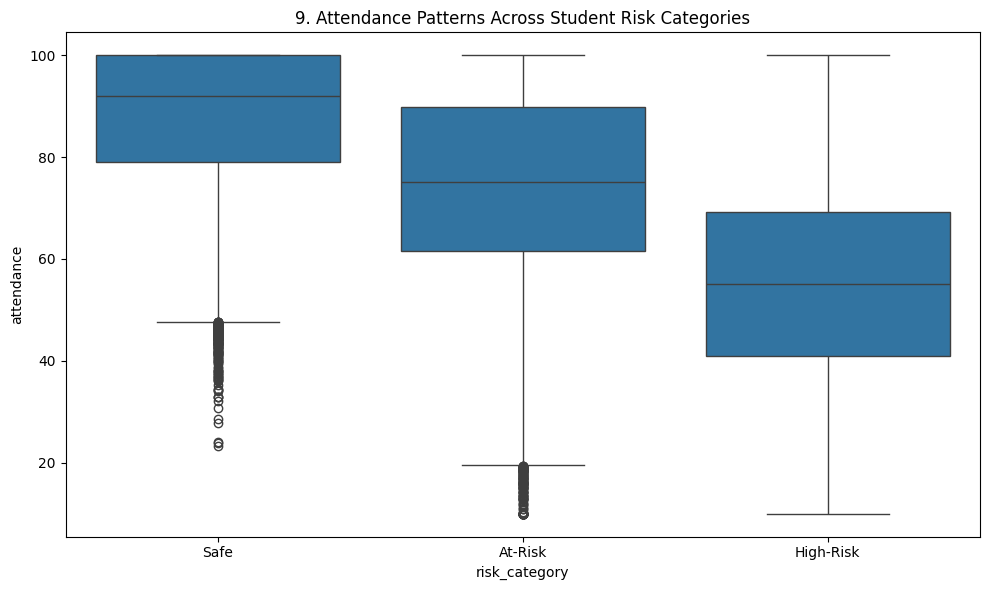

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='risk_category', y='attendance', order=['Safe', 'At-Risk', 'High-Risk'])
plt.title(f'{plot_no}. Attendance Patterns Across Student Risk Categories')
show_fig()
plot_no += 1

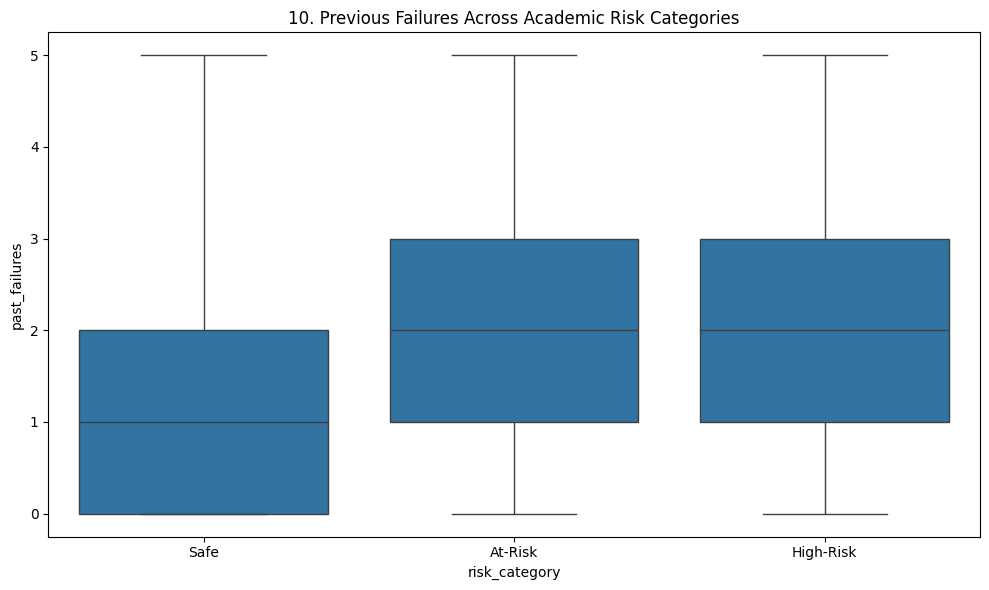

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='risk_category', y='past_failures', order=['Safe', 'At-Risk', 'High-Risk'])
plt.title(f'{plot_no}. Previous Failures Across Academic Risk Categories')
show_fig()
plot_no += 1

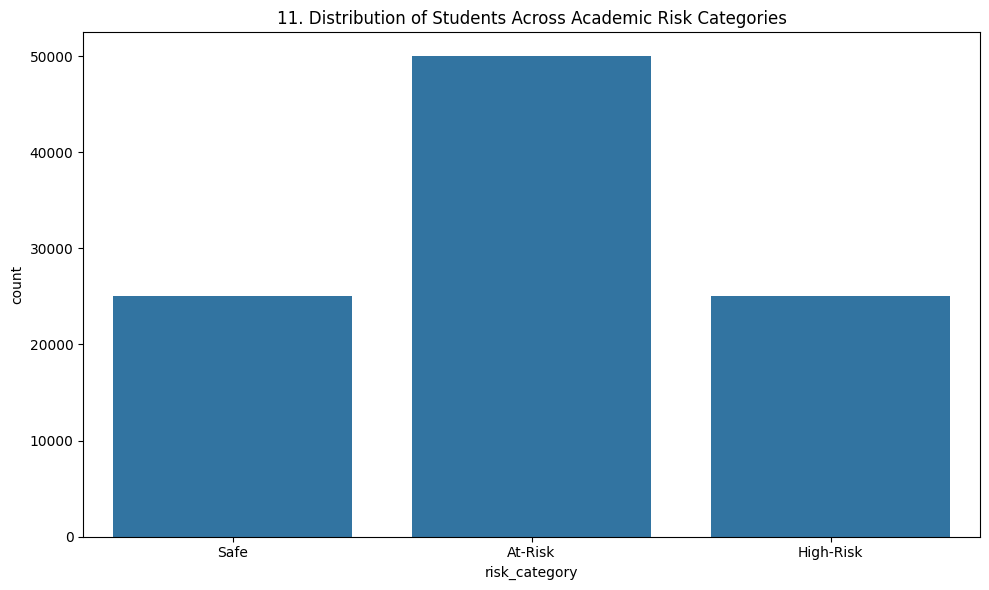

In [24]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='risk_category', order=['Safe', 'At-Risk', 'High-Risk'])
plt.title(f'{plot_no}. Distribution of Students Across Academic Risk Categories')
show_fig()
plot_no += 1

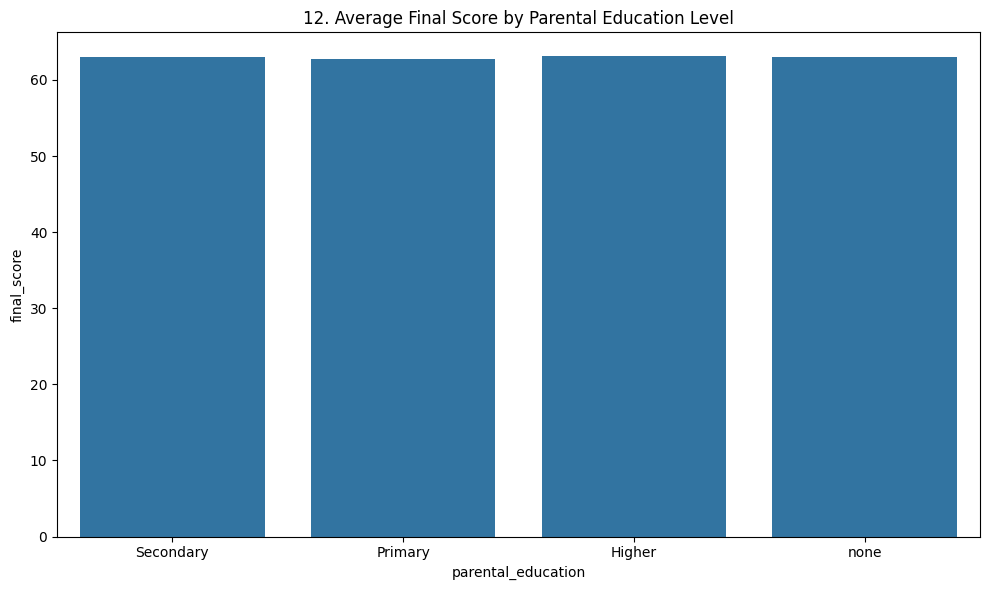

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='parental_education', y='final_score', errorbar=None)
plt.title(f'{plot_no}. Average Final Score by Parental Education Level')
show_fig()
plot_no += 1

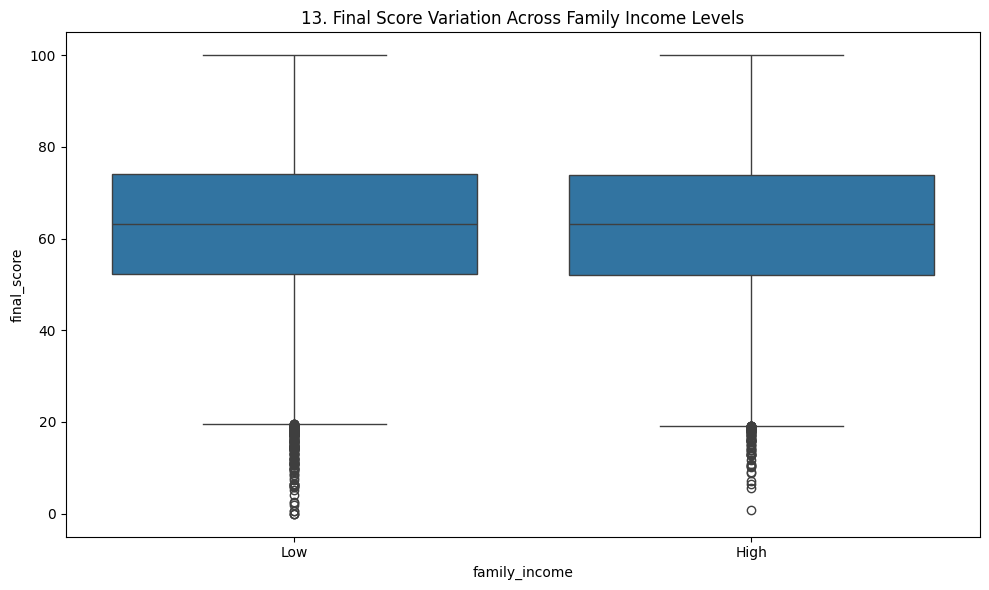

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='family_income', y='final_score', order=['Low', 'High'])
plt.title(f'{plot_no}. Final Score Variation Across Family Income Levels')
show_fig()
plot_no += 1

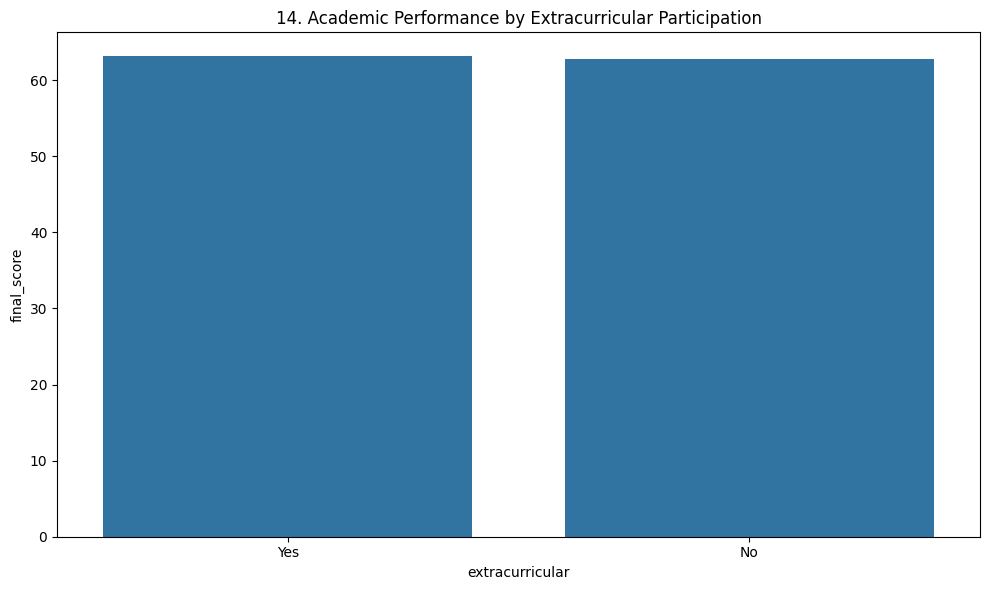

In [27]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='extracurricular', y='final_score', errorbar=None)
plt.title(f'{plot_no}. Academic Performance by Extracurricular Participation')
show_fig()
plot_no += 1

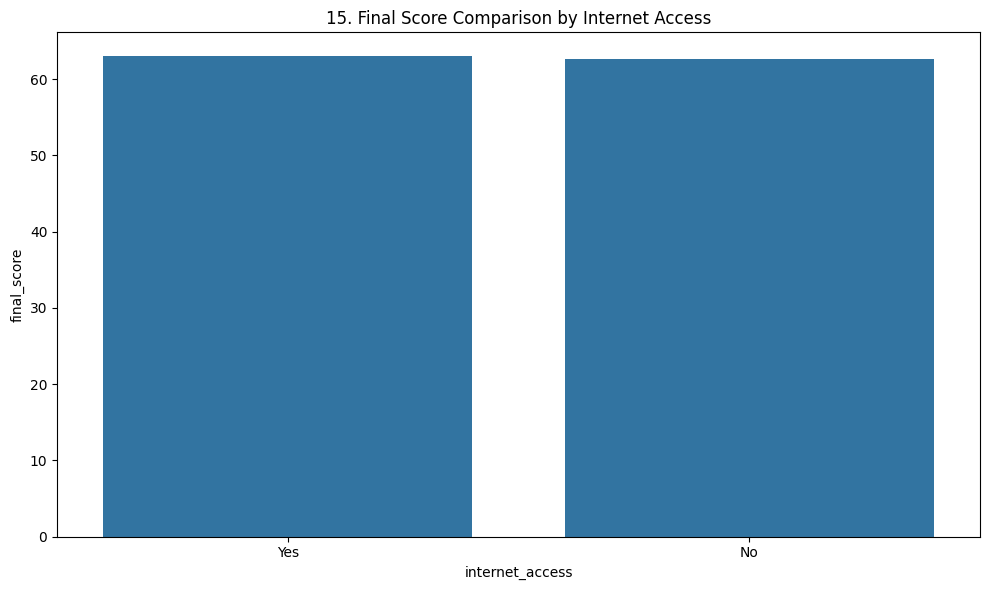

In [28]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='internet_access', y='final_score', errorbar=None)
plt.title(f'{plot_no}. Final Score Comparison by Internet Access')
show_fig()
plot_no += 1

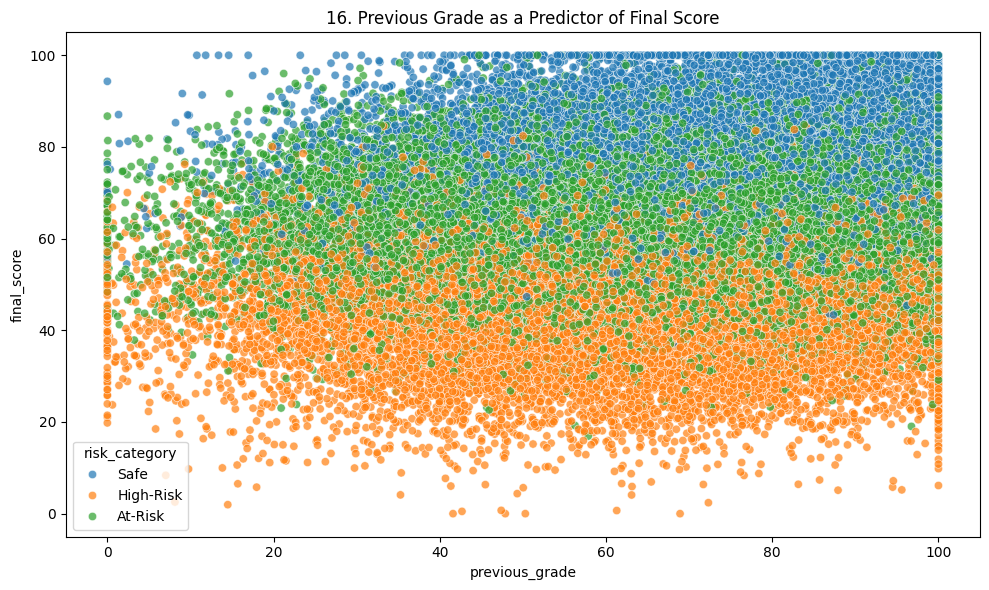

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='previous_grade', y='final_score', hue='risk_category', alpha=0.7)
plt.title(f'{plot_no}. Previous Grade as a Predictor of Final Score')
show_fig()
plot_no += 1

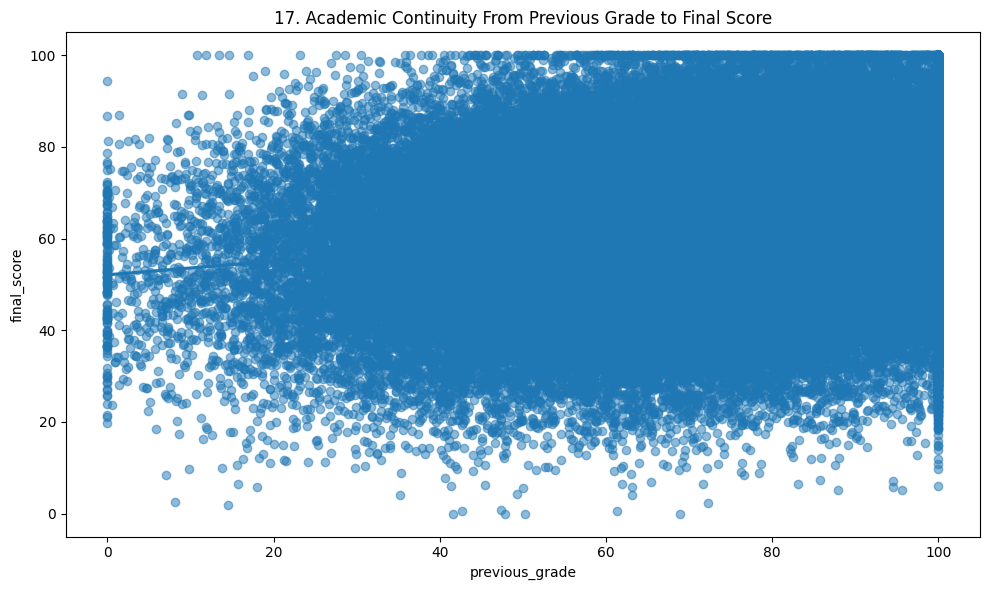

In [30]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='previous_grade', y='final_score', scatter_kws={'alpha':0.5})
plt.title(f'{plot_no}. Academic Continuity From Previous Grade to Final Score')
show_fig()
plot_no += 1

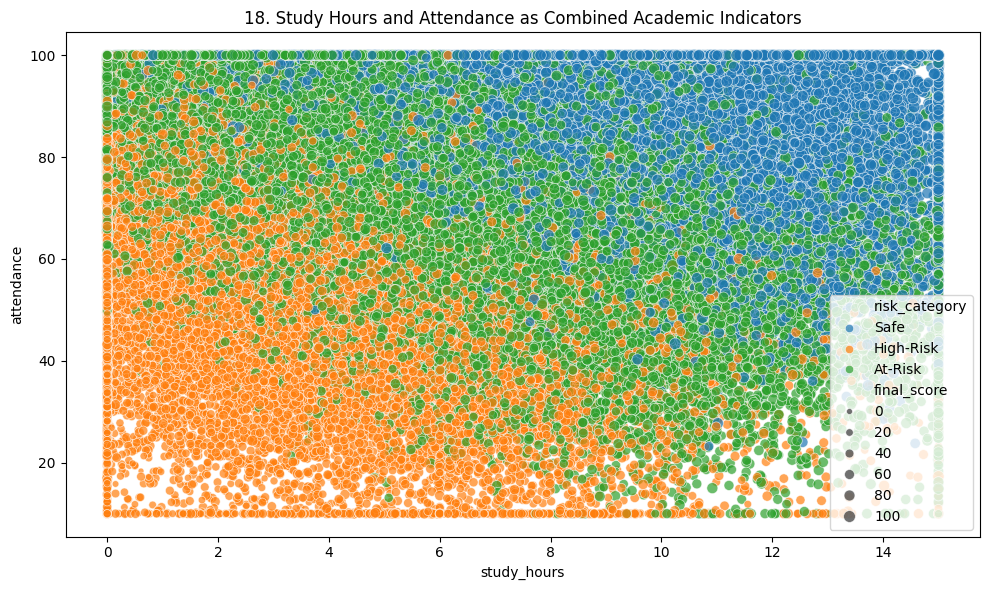

In [31]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='study_hours', y='attendance', size='final_score', hue='risk_category', alpha=0.7)
plt.title(f'{plot_no}. Study Hours and Attendance as Combined Academic Indicators')
show_fig()
plot_no += 1

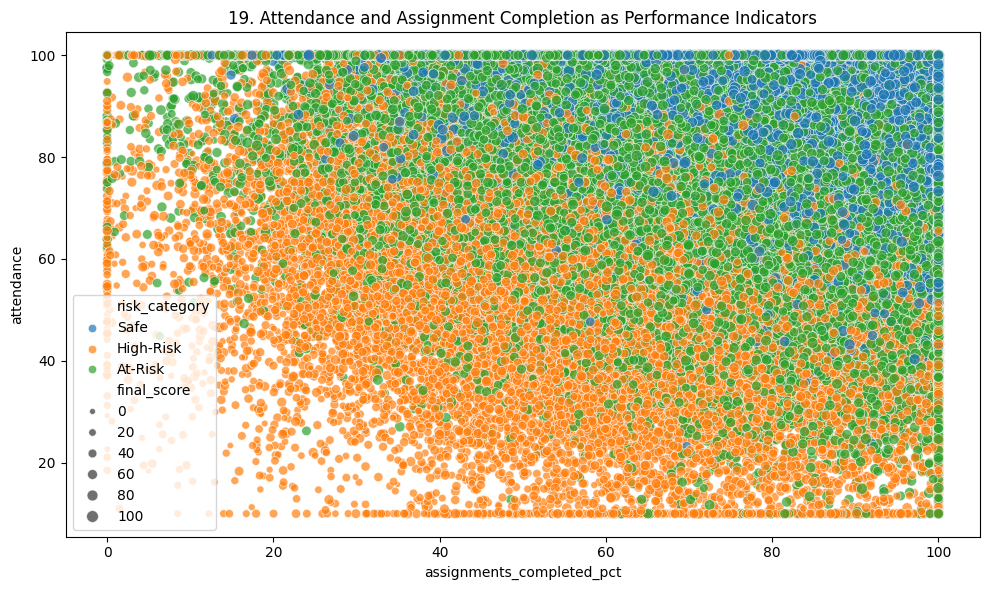

In [32]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='assignments_completed_pct', y='attendance', size='final_score', hue='risk_category', alpha=0.7)
plt.title(f'{plot_no}. Attendance and Assignment Completion as Performance Indicators')
show_fig()
plot_no += 1

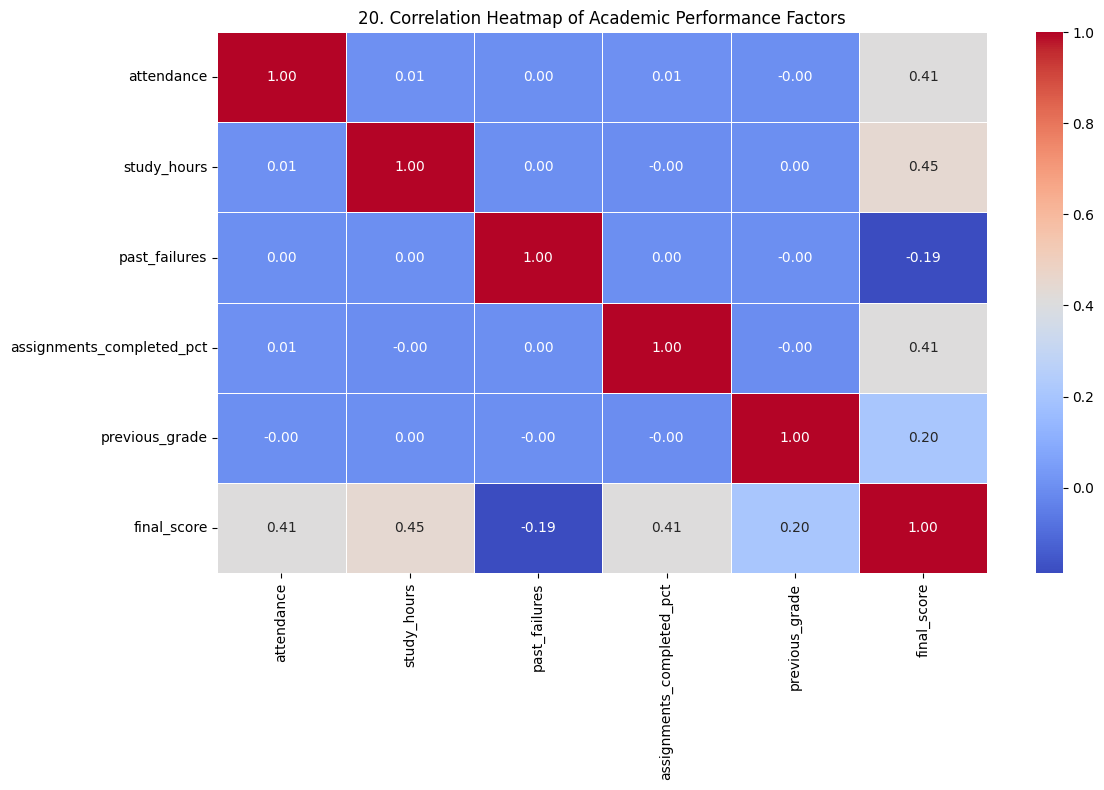

In [33]:
corr = df.select_dtypes(include='number').corr()
fig = plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Academic Performance Factors')
show_fig()
plot_no += 1

# Model Training

## Select features and target

In [34]:
X = df[['attendance', 'study_hours', 'past_failures', 'assignments_completed_pct', 'previous_grade']]
y = df['final_score']

## Split the dataset

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Scale the features

In [36]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train Gradient Boosting model

In [37]:
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

## Make predictions

In [38]:
y_pred = model.predict(X_test)

## Print model performance

In [39]:
print("R² Score:", round(r2_score(y_test, y_pred), 4))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))

R² Score: 0.6046
MAE: 7.9926
RMSE: 9.9943


## Plot actual vs predicted scores

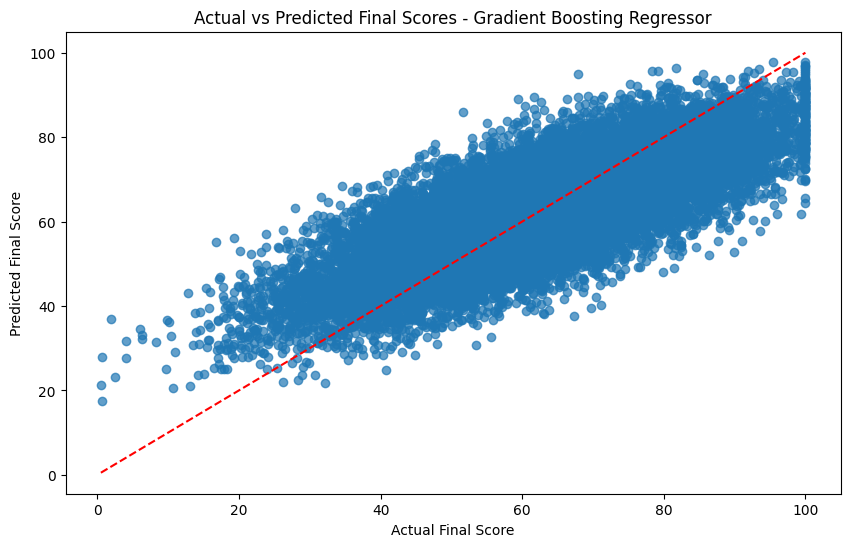

In [40]:
fig = plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Final Score')
plt.ylabel('Predicted Final Score')
plt.title('Actual vs Predicted Final Scores - Gradient Boosting Regressor')
plt.show()